In [1]:
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import xgboost as xgb
import lightgbm as lgb

In [2]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format) 

SEED = 42
np.random.seed(SEED)

# Colour palette we'll reuse in all plots
PALETTE = {
    "primary":   "#3266ad",
    "secondary": "#e07b39",
    "tertiary":  "#2e9e6b",
    "danger":    "#c0392b",
    "light":     "#f4f4f4",
}

In [3]:
DATA_PATH="raw.csv"
df_raw=pd.read_csv(DATA_PATH)

df=df_raw.copy()

---
### **DATA CLEANING**

In [4]:
print(f"Shape: {df.shape}")         # (rows, columns)
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (77299, 11)

Column names:
['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']

First 5 rows:


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.0488,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.1185,Residential,3,Allowed,Yes,31.1046,Sunny
2,2,qp08bj,48,0:0,0.0271,Residential,1,Not Allowed,No,25.9193,Sunny
3,3,qp08gt,48,0:0,0.0033,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.0108,Residential,1,Not Allowed,No,10.8037,Rainy


In [5]:
print(df.dtypes)

Index              int64
geohash              str
day                int64
timestamp            str
demand           float64
RoadType             str
NumberofLanes      int64
LargeVehicles        str
Landmarks            str
Temperature      float64
Weather              str
dtype: object


In [6]:
n_dupes = df.duplicated(subset=["geohash", "day", "timestamp"]).sum() #confirm validation for primary data type
print(f"Dupes: {n_dupes}")

Dupes: 0


In [7]:
for col in df.columns:
    n_unique = df[col].nunique()
    example  = df[col].dropna().iloc[0]
    print(f"  {col:<20} {n_unique:>6}")

  Index                 77299
  geohash                1249
  day                       2
  timestamp                96
  demand                76715
  RoadType                  3
  NumberofLanes             5
  LargeVehicles             2
  Landmarks                 2
  Temperature           74804
  Weather                   4


so index unique, mostly unique demand and temperature hmm

In [8]:
missing = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "percentage null":   df.isnull().mean().mul(100).round(2),
    "dtype":      df.dtypes,
}).query("null_count > 0").sort_values("percentage null", ascending=False)

In [9]:
missing

,null_count,percentage null,dtype
Temperature,2495,3.2300,float64
Weather,797,1.0300,str
RoadType,600,0.7800,str


---
roadtype missing values can be mapped via geohash frequency mapping

In [10]:
geo_roadtype_mode = (
    df.groupby("geohash")["RoadType"]
    .agg(lambda x: x.mode()[0] if x.notna().any() else np.nan)
)

df["RoadType"] = df["RoadType"].fillna(df["geohash"].map(geo_roadtype_mode))

global_roadtype_mode = df["RoadType"].mode()[0]
df["RoadType"] = df["RoadType"].fillna(global_roadtype_mode)

print(f"nulls: {df['RoadType'].isnull().sum()}")
print(df["RoadType"].value_counts())

nulls: 0
RoadType
Residential    69789
Street          3917
Highway         3593
Name: count, dtype: int64


so heavily biased towards residential

---
weather is 4 types, small missingness, so just make it unknown

In [11]:
df["Weather"] = df["Weather"].fillna("Unknown")

print(f"nulls: {df['Weather'].isnull().sum()}")
print(df["Weather"].value_counts())

nulls: 0
Weather
Sunny      27717
Rainy      20824
Foggy      20243
Snowy       7718
Unknown      797
Name: count, dtype: int64


---
temperature left, temp is typicall ycontinuous, so connected to geohash and hour pairs? take median instead o fmean, fill with that?

In [12]:
df["_hour_tmp"] = df["timestamp"].str.split(":").str[0].astype(int)

geo_hour_temp_median = (
    df.groupby(["geohash", "_hour_tmp"])["Temperature"].median()
)

In [13]:
df["_hour_tmp"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [14]:
def fill_temperature(row):
    if pd.isnull(row["Temperature"]):
        key = (row["geohash"], row["_hour_tmp"])
        return geo_hour_temp_median.get(key, np.nan)
    return row["Temperature"]

In [15]:
df["Temperature"] = df.apply(fill_temperature, axis=1)

78 nulls left after this, so just use global median?

In [16]:
global_temp_median = df["Temperature"].median()
df["Temperature"] = df["Temperature"].fillna(global_temp_median)

In [17]:
df.drop(columns=["_hour_tmp"], inplace=True)

In [18]:
print(f"nulls: {df['Temperature'].isnull().sum()}")

nulls: 0


In [19]:
df.isnull().sum()

Index            0
geohash          0
day              0
timestamp        0
demand           0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64

---
### **EDA**

handling skewdness if i go ahead with lstm track, no point for xgboost

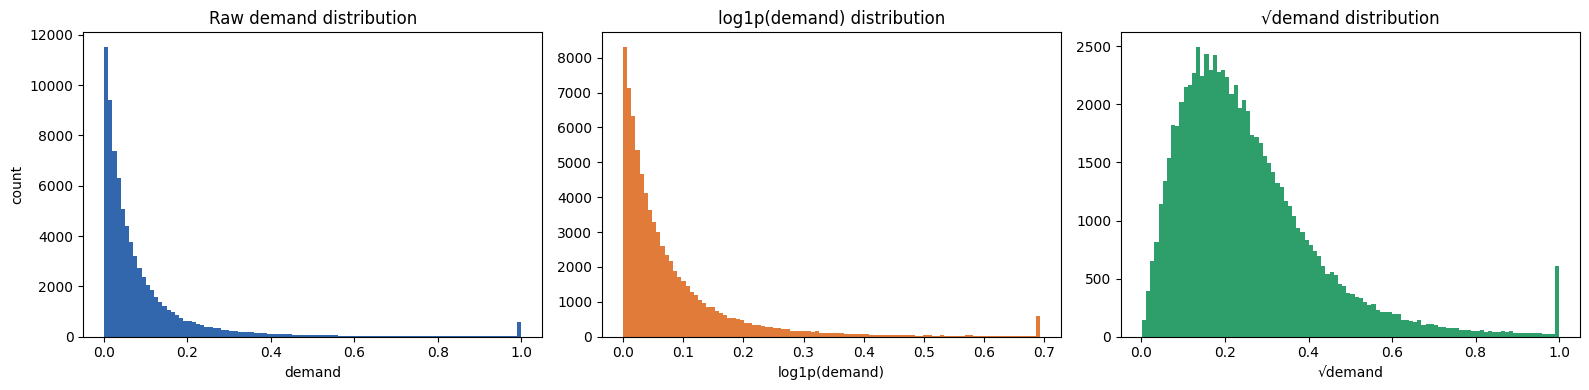

Skewness (raw):    3.7285
Skewness (log1p):  2.9651
Skewness (sqrt):   1.5752

count   77299.0000
mean        0.0939
std         0.1422
min         0.0000
25%         0.0182
50%         0.0478
75%         0.1086
max         1.0000
Name: demand, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["demand"], bins=100, color=PALETTE["primary"], edgecolor="none")
axes[0].set_title("Raw demand distribution")
axes[0].set_xlabel("demand")
axes[0].set_ylabel("count")

axes[1].hist(np.log1p(df["demand"]), bins=100, color=PALETTE["secondary"], edgecolor="none")
axes[1].set_title("log1p(demand) distribution")
axes[1].set_xlabel("log1p(demand)")

axes[2].hist(np.sqrt(df["demand"]), bins=100, color=PALETTE["tertiary"], edgecolor="none")
axes[2].set_title("√demand distribution")
axes[2].set_xlabel("√demand")

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Skewness (raw):    {df['demand'].skew():.4f}")
print(f"Skewness (log1p):  {np.log1p(df['demand']).skew():.4f}")
print(f"Skewness (sqrt):   {np.sqrt(df['demand']).skew():.4f}")
print()
print(df["demand"].describe())

holy skew

In [21]:
# Log1p distribution
print(f"Skewness (log1p):  {np.log1p(df['demand']).skew():.4f}")

Skewness (log1p):  2.9651


not much better

In [22]:
print(f"Skewness (sqrt):   {np.sqrt(df['demand']).skew():.4f}")

Skewness (sqrt):   1.5752


mildly better

Original Skewness: 3.7285
Yeo-Johnson Skewness: 0.4754
Quantile Normal Skewness: 0.6530


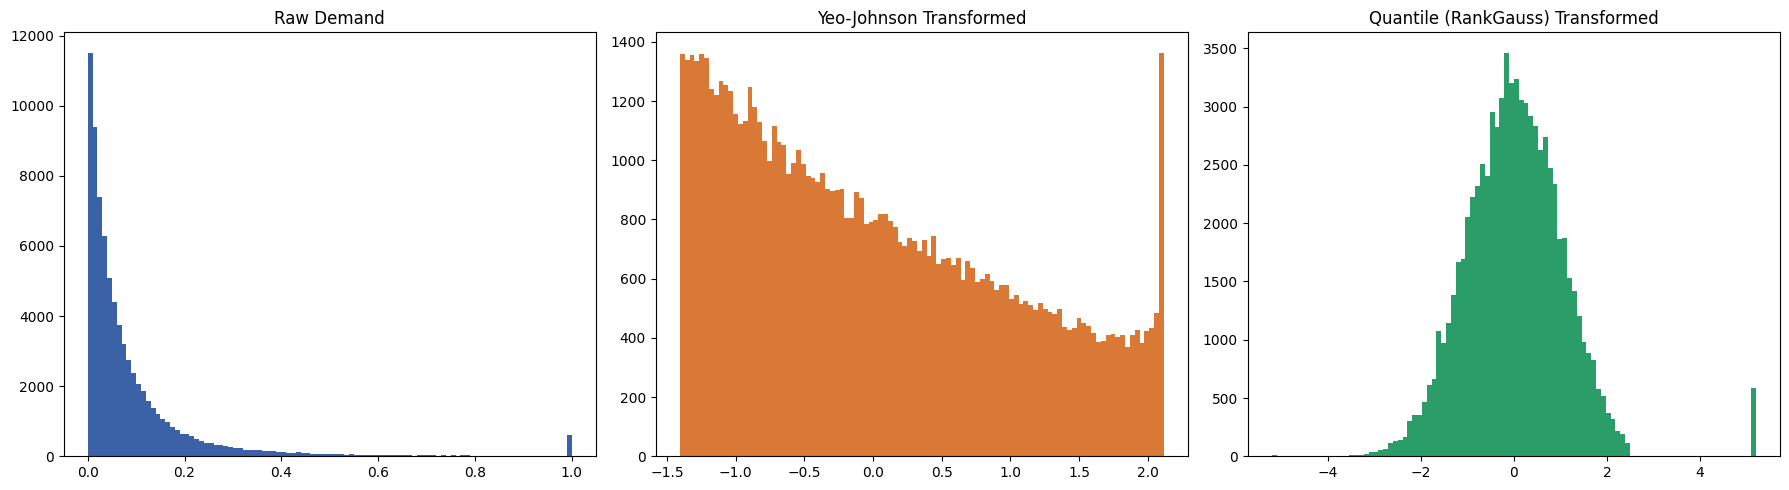

In [23]:
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

demand_data = df[['demand']]

pt_yeo = PowerTransformer(method='yeo-johnson', standardize=True)
df['demand_yeo_johnson'] = pt_yeo.fit_transform(demand_data)

qt_normal = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
df['demand_quantile_normal'] = qt_normal.fit_transform(demand_data)

print(f"Original Skewness: {df['demand'].skew():.4f}")
print(f"Yeo-Johnson Skewness: {df['demand_yeo_johnson'].skew():.4f}")
print(f"Quantile Normal Skewness: {df['demand_quantile_normal'].skew():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['demand'], bins=100, color='#3b62a6')
axes[0].set_title('Raw Demand')

axes[1].hist(df['demand_yeo_johnson'], bins=100, color='#d97935')
axes[1].set_title('Yeo-Johnson Transformed')

axes[2].hist(df['demand_quantile_normal'], bins=100, color='#2a9d68')
axes[2].set_title('Quantile (RankGauss) Transformed')

plt.tight_layout()
plt.show()

well yeo johnson wins

so use yeojohnson at end

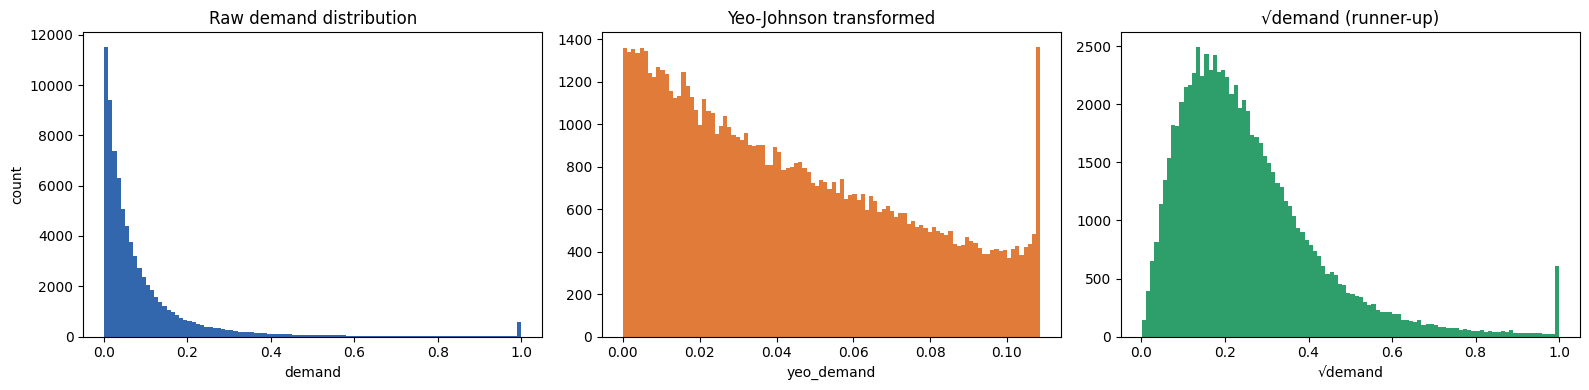

Skewness (raw):          3.7285
Skewness (Yeo-Johnson):  0.4754
Skewness (sqrt):         1.5752

count   77299.0000
mean        0.0939
std         0.1422
min         0.0000
25%         0.0182
50%         0.0478
75%         0.1086
max         1.0000
Name: demand, dtype: float64


In [24]:
pt_yeo_eda = PowerTransformer(method='yeo-johnson', standardize=False)
demand_yeo_eda = pt_yeo_eda.fit_transform(df[["demand"]]).flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw distribution
axes[0].hist(df["demand"], bins=100, color=PALETTE["primary"], edgecolor="none")
axes[0].set_title("Raw demand distribution")
axes[0].set_xlabel("demand")
axes[0].set_ylabel("count")

# Yeo-Johnson distribution
axes[1].hist(demand_yeo_eda, bins=100, color=PALETTE["secondary"], edgecolor="none")
axes[1].set_title("Yeo-Johnson transformed")
axes[1].set_xlabel("yeo_demand")

# Sqrt distribution (shown for comparison)
axes[2].hist(np.sqrt(df["demand"]), bins=100, color=PALETTE["tertiary"], edgecolor="none")
axes[2].set_title("√demand (runner-up)")
axes[2].set_xlabel("√demand")

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print key statistics
print(f"Skewness (raw):          {df['demand'].skew():.4f}")
print(f"Skewness (Yeo-Johnson):  {pd.Series(demand_yeo_eda).skew():.4f}")
print(f"Skewness (sqrt):         {np.sqrt(df['demand']).skew():.4f}")
print()
print(df["demand"].describe())

time structure


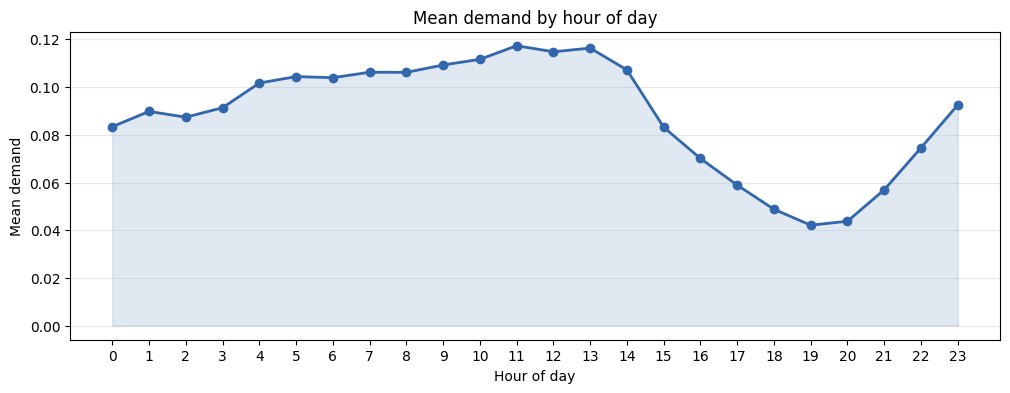

In [25]:
df["hour"]   = df["timestamp"].str.split(":").str[0].astype(int)
df["minute"] = df["timestamp"].str.split(":").str[1].astype(int)
df["time_minutes"] = df["hour"] * 60 + df["minute"]

hourly = df.groupby("hour")["demand"].mean()

plt.figure(figsize=(12, 4))
plt.plot(hourly.index, hourly.values, marker="o", color=PALETTE["primary"], lw=2)
plt.fill_between(hourly.index, hourly.values, alpha=0.15, color=PALETTE["primary"])
plt.xticks(range(0, 24))
plt.xlabel("Hour of day")
plt.ylabel("Mean demand")
plt.title("Mean demand by hour of day")
plt.grid(axis="y", alpha=0.3)
plt.savefig("hourly_demand.png", dpi=150, bbox_inches="tight")
plt.show()

rises slowly, peaks 10 am to 12pm, and stop, so no linear relationship, curve? encode time cyclically, make 11 pm connect backwards to midnight and so forth

In [27]:
print("Row count by day:")
print(df["day"].value_counts().sort_index())

print(f"\nCorrelation of 'day' with demand: {df['day'].corr(df['demand']):.4f}")

Row count by day:
day
48    69427
49     7872
Name: count, dtype: int64

Correlation of 'day' with demand: 0.0268


next to 0 basically, no corelation

rroad type should be a major info provider

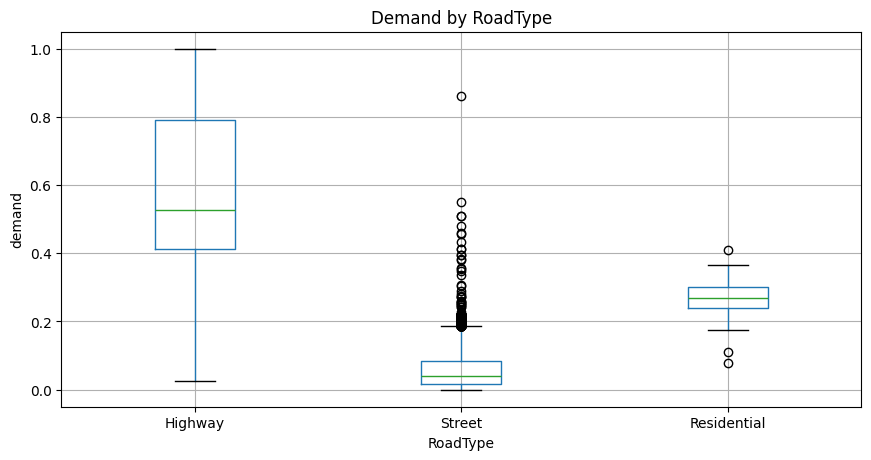

                 count   mean    std    min    25%    50%    75%    max
RoadType                                                               
Highway      3593.0000 0.6094 0.2306 0.0258 0.4134 0.5261 0.7899 1.0000
Residential 69789.0000 0.0573 0.0525 0.0000 0.0162 0.0405 0.0846 0.8607
Street       3917.0000 0.2731 0.0370 0.0784 0.2406 0.2681 0.3019 0.4101


In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
road_order = ["Highway", "Street", "Residential"]

df_plot = df[df["RoadType"].isin(road_order)]
df_plot.boxplot(column="demand", by="RoadType", ax=ax,
                positions=range(len(road_order)))

ax.set_xticklabels(road_order)
ax.set_title("Demand by RoadType")
ax.set_xlabel("RoadType")
ax.set_ylabel("demand")
plt.suptitle("")
plt.savefig("demand_by_roadtype.png", dpi=150, bbox_inches="tight")
plt.show()

# Print exact statistics
print(df.groupby("RoadType")["demand"].describe().round(4))

significant gap between highways and residential, no overlap in these groups, so either model learns boundary or oo we can try seperate models per type

In [29]:
print(df.groupby("NumberofLanes")["demand"].mean().round(4))

NumberofLanes
1   0.0881
2   0.0775
3   0.0779
4   0.6029
5   0.6076
Name: demand, dtype: float64


4 lane, 5 lane multicollinear honestly, same concpet?

In [30]:
for col in ["LargeVehicles", "Landmarks"]:
    print(f"\nMean demand by {col}:")
    print(df.groupby(col)["demand"].mean().round(4))


Mean demand by LargeVehicles:
LargeVehicles
Allowed       0.1319
Not Allowed   0.0740
Name: demand, dtype: float64

Mean demand by Landmarks:
Landmarks
No    0.0963
Yes   0.0928
Name: demand, dtype: float64


weather and temp

          mean    std  count
Weather                     
Foggy   0.0934 0.1411  20243
Rainy   0.0945 0.1416  20824
Snowy   0.0926 0.1383   7718
Sunny   0.0942 0.1444  27717
Unknown 0.0972 0.1458    797


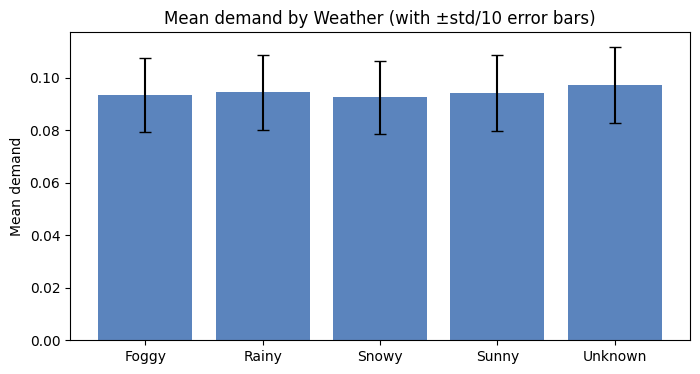

In [31]:
weather_demand = df.groupby("Weather")["demand"].agg(["mean", "std", "count"])
print(weather_demand.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
categories = weather_demand.index.tolist()
means      = weather_demand["mean"].values
stds       = weather_demand["std"].values

ax.bar(categories, means, yerr=stds/10, color=PALETTE["primary"],
       alpha=0.8, capsize=4)
ax.set_ylabel("Mean demand")
ax.set_title("Mean demand by Weather (with ±std/10 error bars)")
plt.savefig("demand_by_weather.png", dpi=150, bbox_inches="tight")
plt.show()

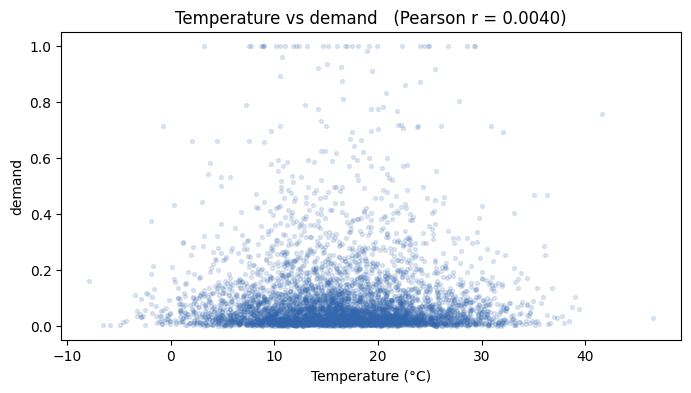

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
sample = df.sample(5000, random_state=SEED)  # subsample for readability
ax.scatter(sample["Temperature"], sample["demand"],
           alpha=0.15, s=8, color=PALETTE["primary"])
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("demand")
ax.set_title(f"Temperature vs demand   (Pearson r = {df['Temperature'].corr(df['demand']):.4f})")
plt.savefig("temperature_vs_demand.png", dpi=150, bbox_inches="tight")
plt.show()

pointless feature

now the real problem how important is the location

In [33]:
print(f"Unique geohashes: {df['geohash'].nunique()}")

geo_counts = df["geohash"].value_counts()
print(f"\nObservations per geohash:")
print(geo_counts.describe().round(1))

print(f"\nMost common count: {geo_counts.mode()[0]}")

Unique geohashes: 1249

Observations per geohash:
count   1249.0000
mean      61.9000
std       35.7000
min        1.0000
25%       30.0000
50%       71.0000
75%       94.0000
max      105.0000
Name: count, dtype: float64

Most common count: 105


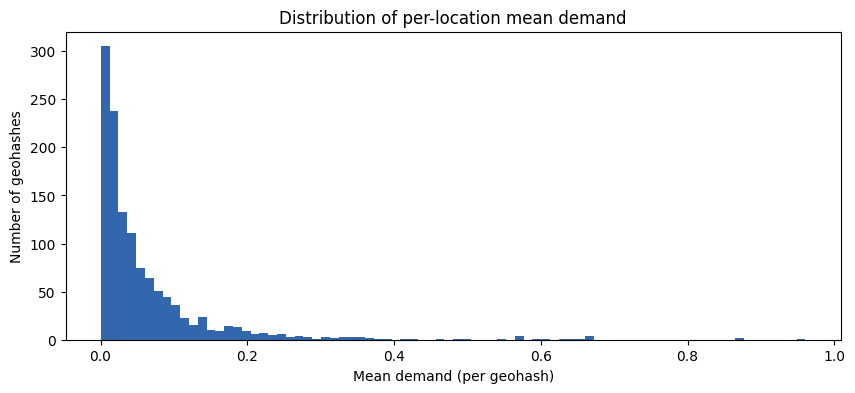


Geohash mean demand — std: 0.0999
Overall demand std: 0.1422

→ Most of the total variance is between locations, not within them over time.


In [ ]:
geo_demand = df.groupby("geohash")["demand"].mean()

plt.figure(figsize=(10, 4))
plt.hist(geo_demand, bins=80, color=PALETTE["primary"], edgecolor="none")
plt.xlabel("Mean demand (per geohash)")
plt.ylabel("Number of geohashes")
plt.title("Distribution of per-location mean demand")
plt.savefig("geo_demand_hist.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nGeohash mean demand — std: {geo_demand.std():.4f}")
print(f"Overall demand std: {df['demand'].std():.4f}")

In [36]:
# Spatial autocorrelation: do nearby locations (same 5-char prefix) have similar demand?
df["geo5"] = df["geohash"].str[:5]
geo5_mean  = df.groupby("geo5")["demand"].mean()
df["geo5_demand_mean"] = df["geo5"].map(geo5_mean)

spatial_corr = df["demand"].corr(df["geo5_demand_mean"])
print(f"Correlation between demand and neighbour 5 char mean: {spatial_corr:.4f}")

Correlation between demand and neighbour 5 char mean: 0.3794


worth a feature

build autocorelation features, does past affect future? i.e demand just before predict demand now? actual time series?

In [37]:
df = df.sort_values(["geohash", "day", "time_minutes"]).reset_index(drop=True)

In [ ]:
df["demand_lag1"] = df.groupby(["geohash", "day"])["demand"].shift(1)
df["demand_lag2"] = df.groupby(["geohash", "day"])["demand"].shift(2)
df["demand_lag4"] = df.groupby(["geohash", "day"])["demand"].shift(4)

lag1_corr = df["demand"].corr(df["demand_lag1"])
lag2_corr = df["demand"].corr(df["demand_lag2"])

print(f"Lag-1 autocorrelation: {lag1_corr:.4f}")
print(f"Lag-2 autocorrelation: {lag2_corr:.4f}")

Lag-1 autocorrelation: 0.9714
Lag-2 autocorrelation: 0.9559


oh dear, definitely a time series

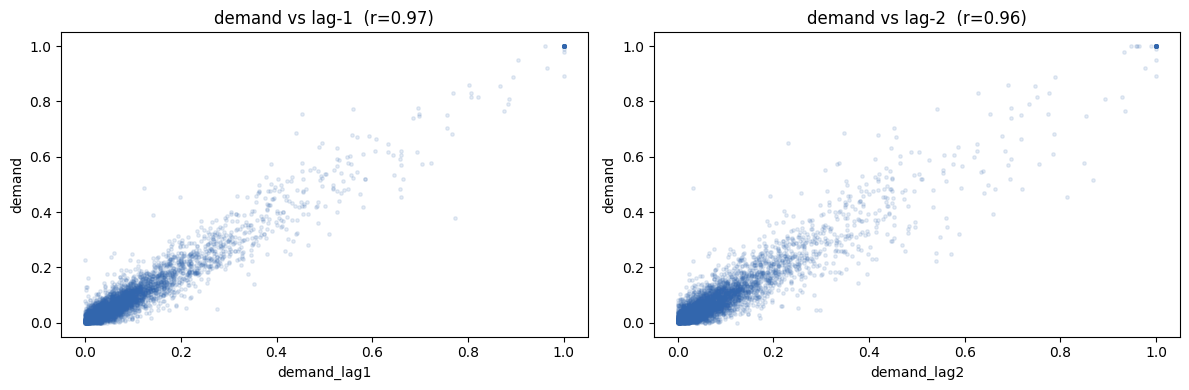

In [40]:
sample = df.dropna(subset=["demand_lag1"]).sample(5000, random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (lag_col, title) in zip(axes, [
    ("demand_lag1", f"demand vs lag-1  (r={lag1_corr:.2f})"),
    ("demand_lag2", f"demand vs lag-2  (r={lag2_corr:.2f})")
]):
    ax.scatter(sample[lag_col], sample["demand"],
               alpha=0.12, s=6, color=PALETTE["primary"])
    ax.set_xlabel(lag_col)
    ax.set_ylabel("demand")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("autocorrelation_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

yep a time series

---
## **Feature Engineering**

parse timestamps

In [41]:
df["hour"]         = df["timestamp"].str.split(":").str[0].astype(int)
df["minute"]       = df["timestamp"].str.split(":").str[1].astype(int)
df["time_minutes"] = df["hour"] * 60 + df["minute"]

In [42]:
print(f"time_minutes range: {df['time_minutes'].min()} to {df['time_minutes'].max()}")

time_minutes range: 0 to 1425


time encoding to make it cyclical i.e make time continuous

In [44]:
PERIOD = 1440

df["time_sin"] = np.sin(2 * np.pi * df["time_minutes"] / PERIOD)
df["time_cos"] = np.cos(2 * np.pi * df["time_minutes"] / PERIOD)

rolling window feature, combine what the lag features were sorta doing

In [46]:
df["demand_roll4_mean"] = (
    df.groupby(["geohash", "day"])["demand"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).mean())
)

df["demand_roll4_std"] = (
    df.groupby(["geohash", "day"])["demand"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=2).std())
)
df["demand_roll4_std"] = df["demand_roll4_std"].fillna(0)

In [47]:

print("Rolling features sample:")
print(df[["geohash", "day", "time_minutes", "demand",
          "demand_lag1", "demand_roll4_mean", "demand_roll4_std"]].head(12))

Rolling features sample:
   geohash  day  time_minutes  demand  demand_lag1  demand_roll4_mean  \
0   qp02yc   48            60  0.0054          NaN                NaN   
1   qp02yc   48           150  0.0129       0.0054             0.0054   
2   qp02yc   48           165  0.0260       0.0129             0.0092   
3   qp02yc   48           210  0.0264       0.0260             0.0148   
4   qp02yc   48           390  0.0084       0.0264             0.0177   
5   qp02yc   48           405  0.0208       0.0084             0.0184   
6   qp02yc   48           420  0.0049       0.0208             0.0204   
7   qp02yc   48           435  0.0271       0.0049             0.0151   
8   qp02yc   48           450  0.0048       0.0271             0.0153   
9   qp02yc   48           540  0.0174       0.0048             0.0144   
10  qp02yc   48           630  0.0468       0.0174             0.0135   
11  qp02yc   48           645  0.0212       0.0468             0.0240   

    demand_roll4_std  
0 

engineering a feature for neighbours, compute later inside train val split

In [48]:
df["geo5"] = df["geohash"].str[:5]

In [49]:
df["geo5"]

0        qp02y
1        qp02y
2        qp02y
3        qp02y
4        qp02y
         ...  
77294    qp0dn
77295    qp0dn
77296    qp0dn
77297    qp0dn
77298    qp0dn
Name: geo5, Length: 77299, dtype: str

encode geohash lmao because one hot deffinitely wont work, and boosted trees would handle it by itself, but i wanna try regression first

In [50]:
def target_encode(train_series, target_series, val_series=None, smoothing=10):
    """
    Encode a categorical column using smoothed target means from the training set.

    Parameters
    ----------
    train_series : pd.Series   — the categorical column in the training set
    target_series : pd.Series  — the target column in the training set (same index)
    val_series    : pd.Series  — the categorical column in the val/test set (optional)
    smoothing     : int        — strength of shrinkage towards global mean

    Returns
    -------
    train_encoded, val_encoded  — numeric arrays
    """
    global_mean = target_series.mean()

    # Per-category statistics from training data
    stats = (
        pd.DataFrame({"cat": train_series, "target": target_series})
        .groupby("cat")["target"]
        .agg(["mean", "count"])
    )
    stats["encoded"] = (
        (stats["count"] * stats["mean"] + smoothing * global_mean)
        / (stats["count"] + smoothing)
    )
    mapping = stats["encoded"].to_dict()

    train_encoded = train_series.map(mapping).fillna(global_mean)
    val_encoded   = val_series.map(mapping).fillna(global_mean) if val_series is not None else None

    return train_encoded, val_encoded


transform target using jeo johnson as well

In [51]:
from sklearn.preprocessing import PowerTransformer

pt_yeo = PowerTransformer(method='yeo-johnson', standardize=False)
df["yeo_demand"] = pt_yeo.fit_transform(df[["demand"]]).flatten()

In [53]:

print(f"demand — skewness: {df['demand'].skew():.4f}")
print(f"yeo_demand — skewness: {df['yeo_demand'].skew():.4f}")

demand — skewness: 3.7285
yeo_demand — skewness: 0.4754


---
## **TRAIN VALIDATION SPLIT YAYY**

timeseries, so cant randomly shuffle, so split by time? so have time zones, and we already have seperations by day 48 and day 49 in a premade train test split of 90-10 (flipkart did you do this intentionally)

In [54]:
df_train = df[df["day"] == 48].copy()
df_val   = df[df["day"] == 49].copy()

pt_yeo = PowerTransformer(method='yeo-johnson', standardize=False)
df_train["yeo_demand"] = pt_yeo.fit_transform(df_train[["demand"]]).flatten()

df_val["yeo_demand"] = pt_yeo.transform(df_val[["demand"]]).flatten()

In [55]:

print(f"Train yeo_demand — skewness: {df_train['yeo_demand'].skew():.4f}")
print(f"Val   yeo_demand — skewness: {df_val['yeo_demand'].skew():.4f}")

print(f"Training rows:   {len(df_train):,}  ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validation rows: {len(df_val):,}  ({len(df_val)/len(df)*100:.1f}%)")

Train yeo_demand — skewness: 0.4803
Val   yeo_demand — skewness: 0.3136
Training rows:   69,427  (89.8%)
Validation rows: 7,872  (10.2%)


removing lag where you cant have lag features lol

In [56]:
lag_cols = ["demand_lag1", "demand_lag2"]

n_before = len(df_train)
df_train = df_train.dropna(subset=lag_cols)
print(f"Training rows dropped (no lag): {n_before - len(df_train):,}")

n_before = len(df_val)
df_val = df_val.dropna(subset=lag_cols)
print(f"Validation rows dropped (no lag): {n_before - len(df_val):,}")

Training rows dropped (no lag): 2,441
Validation rows dropped (no lag): 2,098


apply target encodings for geohash, compute from training set, apply to train and validation

In [ ]:
df_train["geohash_encoded"], df_val["geohash_encoded"] = target_encode(
    train_series  = df_train["geohash"],
    target_series = df_train["demand"],   # use raw demand for the encoding mean
    val_series    = df_val["geohash"],
    smoothing     = 15,
)

Geohash target encoding applied.
Train geohash_encoded — mean: 0.0977


In [59]:
print("Geohash target encoding applied.")
print(f"Train geohash_encoded — mean: {df_train['geohash_encoded'].mean():.4f}")

Geohash target encoding applied.
Train geohash_encoded — mean: 0.0977


spatial neighbour feature, compute mean demand from training data

In [60]:
geo5_time_mean = (
    df_train.groupby(["geo5", "time_minutes"])["demand"]
    .mean()
    .rename("geo5_time_demand_mean")
    .reset_index()
)

df_train = df_train.merge(geo5_time_mean, on=["geo5", "time_minutes"], how="left")
df_val   = df_val.merge(geo5_time_mean, on=["geo5", "time_minutes"], how="left")

global_demand_mean = df_train["demand"].mean()
df_train["geo5_time_demand_mean"] = df_train["geo5_time_demand_mean"].fillna(global_demand_mean)
df_val["geo5_time_demand_mean"]   = df_val["geo5_time_demand_mean"].fillna(global_demand_mean)

encode numerically, binary columns 0/1 mapping, road type gets one-hot

In [61]:
df_train["LargeVehicles_enc"] = (df_train["LargeVehicles"] == "Allowed").astype(int)
df_val["LargeVehicles_enc"]   = (df_val["LargeVehicles"]   == "Allowed").astype(int)

df_train["Landmarks_enc"] = (df_train["Landmarks"] == "Yes").astype(int)
df_val["Landmarks_enc"]   = (df_val["Landmarks"]   == "Yes").astype(int)

df_train = pd.get_dummies(df_train, columns=["RoadType"], drop_first=True)
df_val   = pd.get_dummies(df_val,   columns=["RoadType"], drop_first=True)

for col in df_train.columns:
    if col not in df_val.columns:
        df_val[col] = 0

df_train = pd.get_dummies(df_train, columns=["Weather"], drop_first=True)
df_val   = pd.get_dummies(df_val,   columns=["Weather"], drop_first=True)

for col in df_train.columns:
    if col not in df_val.columns:
        df_val[col] = 0


final features list

In [62]:
FEATURES = [
    "demand_lag1", "demand_lag2", "demand_lag4",
    "demand_roll4_mean", "demand_roll4_std",
    "time_sin", "time_cos", "time_minutes", "hour",
    "NumberofLanes", "LargeVehicles_enc", "Landmarks_enc",
    *[c for c in df_train.columns if c.startswith("RoadType_")],
    *[c for c in df_train.columns if c.startswith("Weather_")],
    "Temperature",
    "geohash_encoded", "geo5_time_demand_mean",
]

In [63]:
missing_features = [f for f in FEATURES if f not in df_train.columns]
assert len(missing_features) == 0, f"Missing features: {missing_features}"

AssertionError: Missing features: ['demand_lag4']